(chap_aihc_feature_engineering)=
# Feature Engineering in Healthcare Without Time Travel

**Content creators:** [Abhishek](https://github.com/moturuab)

**Developer:** T-CAIREM Education  
**Estimated time:** about 30 minutes for the core route; 15–25 minutes for optional diagnostics  
**Level:** introductory Python and machine learning  
**Compute:** CPU only; no download, GPU, or external service is required

## At a glance

| Question | This notebook's answer |
|---|---|
| What is the prediction task? | At hour 0, estimate whether a fictional patient will experience a deterioration event in the next 12 hours. |
| Why is the event stream simulated? | We need exact control over collection time, result-availability time, unmeasured severity, and a deliberately future feature so leakage is known rather than guessed. This is the intended dataset—not a fallback. |
| Which models are compared? | Prevalence baseline, last-value logistic regression, engineered-feature logistic regression, random forest, and gradient boosting. |
| What improvement should we expect? | A modest ladder from weak to stronger valid pipelines, not near-perfect discrimination. Irreducible outcome noise is built into the generator. |
| How is evaluation protected? | Patient-level train, validation, calibration, and test splits; train-only learned transforms; validation-only model selection; calibration-only threshold selection; one final test evaluation. |
| What is the cautionary comparison? | A model given a moderately informative future measurement improves for the wrong reason. It is kept outside model selection and never treated as a valid candidate. |

## The 30-minute core route

Follow Sections 1–3 to define the prediction contract and understand point-in-time availability. Run Sections 4–8 to engineer features, compare candidates, freeze the family and threshold, and open the locked test set once. Section 9 is the deliberate leakage demonstration. Sections 10–11 are optional calibration, importance, subgroup, and contract-check diagnostics; Sections 12–14 extend and summarize the lesson. Long generation and aggregation cells are collapsed in the website version.

## Learning objectives

By the end, you should be able to:

1. write a prediction contract with an index time, lookback window, outcome window, and unit of analysis;
2. distinguish measurement time from the time a result was actually available;
3. construct last value, change, slope, variability, range, recency, and missingness features;
4. fit preprocessing only on training data through a pipeline;
5. compare feature sets and model families without opening the test set; and
6. recognize why a better score can be evidence of leakage rather than better clinical prediction.

:::{admonition} Scope and results disclaimer
:class: warning
This notebook uses a purpose-built fictional event stream. The variables have familiar names so the feature logic is readable, but their distributions are not calibrated to any hospital or population. All prevalence, missingness, coefficients, model rankings, thresholds, and confidence intervals are properties of the generator and random seed. They must not be interpreted as epidemiology, clinical utility, or expected real-world performance.
:::


In [1]:
# Core numerical and tabular tools.
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Scikit-learn components are kept inside pipelines so every learned
# transform is fitted on the correct split only.
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Reproducibility is important for a tutorial whose exact outputs are discussed.
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=FutureWarning)


## 1. Freeze the prediction contract before writing features

A feature is not “available” merely because it exists somewhere in a database. Its validity depends on the exact prediction moment. We will use this contract:

| Contract element | Definition in this tutorial | Why it matters |
|---|---|---|
| Unit of analysis | One fictional patient encounter | Determines what a row means and how to split data |
| Index time | Hour 0 | The latest moment the model may know anything |
| Lookback window | Hours −12 through 0 | Bounds the historical evidence used for features |
| Outcome window | More than 0 through +12 hours | Separates predictors from the future event |
| Outcome | Simulated deterioration indicator | Provides a binary teaching label, not a clinical definition |
| Intended use | Demonstrate point-in-time feature construction | Explicitly excludes clinical decision support |

The rule for an input event is stricter than “collection time ≤ 0.” Both its measurement time **and its result-availability time** must be at or before hour 0. A specimen collected at hour −1 but reported at +1 was not visible to a model running at hour 0.


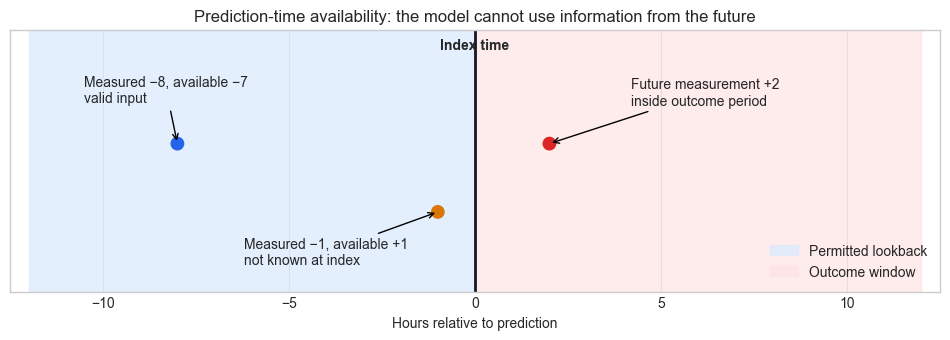

In [2]:
# The timeline is generated with Matplotlib so it remains self-contained.
fig, ax = plt.subplots(figsize=(12, 3.4))
# Phase 1: colour the legal history and prohibited outcome periods.
ax.axvspan(-12, 0, color="#dbeafe", alpha=0.75, label="Permitted lookback")
ax.axvspan(0, 12, color="#fee2e2", alpha=0.65, label="Outcome window")
ax.axvline(0, color="#111827", linewidth=2)
ax.text(0, 1.05, "Index time", ha="center", va="bottom", fontweight="bold")

# Two events demonstrate why collection and availability are different clocks.
ax.scatter([-8, -1, 2], [0.65, 0.35, 0.65], s=80,
           color=["#2563eb", "#d97706", "#dc2626"], zorder=3)
ax.annotate("Measured −8, available −7\nvalid input", (-8, 0.65),
            xytext=(-10.5, 0.83), arrowprops={"arrowstyle": "->"})
ax.annotate("Measured −1, available +1\nnot known at index", (-1, 0.35),
            xytext=(-6.2, 0.12), arrowprops={"arrowstyle": "->"})
ax.annotate("Future measurement +2\ninside outcome period", (2, 0.65),
            xytext=(4.2, 0.82), arrowprops={"arrowstyle": "->"})
ax.set(xlim=(-12.5, 12.5), ylim=(0, 1.15), xlabel="Hours relative to prediction",
       yticks=[])
ax.legend(loc="lower right")
ax.set_title("Prediction-time availability: the model cannot use information from the future")
plt.show()


The orange result is a common leakage trap. It was collected during the lookback, so a retrospective SQL query filtered only on collection time would include it. Operationally, however, the model could not have seen the result until one hour after prediction. The red measurement is even more obviously future information.

A useful feature specification therefore needs at least five fields: source table, variable, aggregation, lookback, and availability rule. “Latest creatinine” is incomplete; “latest reported creatinine with collection and result-availability times at or before the index” is auditable.


## 2. Why a purpose-built simulated event stream?

This notebook is specifically about **temporal correctness**. A convenient public table rarely provides both the time a value was measured and the time it became available to a prediction service. It also cannot tell us with certainty which unrecorded latent factors generated the label. We therefore construct the intended teaching dataset ourselves.

The generator includes:

- patient-level baseline differences that make a single last value noisy;
- subtle worsening trends that engineered slopes and changes can capture;
- informative observation frequency, reflecting that sicker fictional patients may be measured more often;
- delayed laboratory results that must be excluded at the index time;
- nonlinear interactions that can give tree models a modest advantage; and
- irreducible Bernoulli noise so no valid model should be close to perfect.

This control is the benefit. Lack of external validity is the cost. We will never call the synthetic patients “real,” and we will not use the resulting performance numbers to make claims about clinical models.

:::{admonition} What the simulation does—and does not—justify
:class: caution
It justifies checking whether our code obeys a known time boundary and whether progressively richer features recover some deliberately embedded signal. It does not justify the causal relationships, effect sizes, subgroup patterns, prevalence, or model ranking outside this notebook. A real project must repeat the entire analysis with governed, representative local data and a clinically reviewed outcome definition.
:::


## 3. Generate patients, outcomes, and timestamped observations

We first create one encounter-level row per fictional patient. `acute_burden` and `worsening` are hidden generator variables: they influence both measurements and outcome probability but will **not** be given directly to any model. Their only purpose is to create a controlled but imperfect statistical problem.

Outcome generation includes a random Bernoulli draw. Two patients with similar hidden risk can therefore have different outcomes, just as many clinical outcomes are not deterministically predictable from available measurements. This irreducible uncertainty prevents unrealistic near-perfect results.


In [3]:
# A larger sample makes the model comparison stable while remaining fast on CPU.
n_patients = 3_600
patient_ids = np.array([f"FE-{i:05d}" for i in range(n_patients)])

# Demographics and context are fictional and intentionally simplified.
age = np.clip(rng.normal(62, 15, n_patients), 18, 95)
comorbidity_count = np.clip(rng.poisson(1.7, n_patients), 0, 6)
sex_for_audit = rng.choice(["F", "M"], n_patients, p=[0.52, 0.48])
care_site = rng.choice(["A", "B", "C", "D"], n_patients,
                       p=[0.34, 0.28, 0.23, 0.15])

# Hidden generator variables create patient-specific state and trajectory.
acute_burden = rng.normal(0, 1, n_patients)
worsening = 0.25 * acute_burden + rng.normal(0, 1, n_patients)
unmeasured_context = rng.normal(0, 0.75, n_patients)

# Nonlinear interactions give flexible models something modest to learn.
age_z = (age - 62) / 15
high_risk_interaction = ((acute_burden > 0.7) & (worsening > 0.45)).astype(float)
site_effect = np.select([care_site == "B", care_site == "D"], [0.10, 0.25], default=0.0)

# The outcome is stochastic by design; observed features cannot perfectly recover it.
outcome_logit = (
    -1.55
    + 0.30 * age_z
    + 0.20 * comorbidity_count
    + 0.15 * acute_burden
    + 0.52 * worsening
    + 1.60 * high_risk_interaction
    + site_effect
    + 0.48 * unmeasured_context
)
event_probability = 1 / (1 + np.exp(-outcome_logit))
event_12h = rng.binomial(1, event_probability)

patients = pd.DataFrame({
    "patient_id": patient_ids,
    "age": age.round(1),
    "comorbidity_count": comorbidity_count,
    "sex_for_audit": sex_for_audit,
    "care_site": care_site,
    "event_12h": event_12h,
})

print(f"Fictional encounters: {len(patients):,}")
print(f"Simulated event prevalence: {patients.event_12h.mean():.1%}")
display(patients.head())


Fictional encounters: 3,600
Simulated event prevalence: 28.7%


,patient_id,age,comorbidity_count,sex_for_audit,care_site,event_12h
0,FE-00000,66.6,0,F,A,0
1,FE-00001,46.4,3,F,A,0
2,FE-00002,73.3,0,F,C,0
3,FE-00003,76.1,1,F,C,0
4,FE-00004,32.7,2,F,D,0


Next we generate a long-format event stream. Each row records one measurement, its clinical clock (`measurement_hour`), and its information-system clock (`available_hour`). Patient-specific baselines intentionally obscure the relationship between a single value and deterioration; change over time is often more informative.

Observation probability also varies slightly with hidden burden and time. Consequently, `count` and `was_measured` can encode workflow as well as physiology. Such process features may be predictive yet fragile: a staffing or ordering-policy change can alter them without any change in patient health.


In [4]:
measurement_hours = np.array([-12.0, -8.0, -4.0, 0.0])
variable_specs = {
    # base, patient-baseline spread, acute effect, worsening slope, measurement noise
    "heart_rate":       (78.0, 8.0,  2.0,  10.0, 6.2),
    "spo2":             (96.0, 1.4, -0.4,  -3.6, 1.2),
    "respiratory_rate": (17.0, 2.8,  0.5,   5.0, 2.3),
    "systolic_bp":      (122.0, 11.0, -1.0, -8.0, 8.5),
    "creatinine":       (0.95, 0.22, 0.03, 0.30, 0.13),
}

# Create stable patient baselines once; this makes within-patient changes useful.
patient_baselines = {
    variable: rng.normal(0, spec[1], n_patients)
    for variable, spec in variable_specs.items()
}

observation_rows: list[dict] = []
for patient_index, patient_id in enumerate(patient_ids):
    for variable, (base, _, acute_effect, slope_effect, noise_sd) in variable_specs.items():
        for measurement_hour in measurement_hours:
            progress = (measurement_hour + 12.0) / 12.0  # 0 at −12 h; 1 at index

            # Measurements are somewhat more frequent near the index and for
            # higher-burden fictional patients. This creates informative missingness.
            observe_logit = (
                0.90 + 0.18 * acute_burden[patient_index]
                + 0.16 * max(worsening[patient_index], 0.0)
                + 0.25 * progress - (0.25 if variable == "creatinine" else 0.0)
            )
            observe_probability = 1 / (1 + np.exp(-observe_logit))
            if rng.random() > observe_probability:
                continue

            value = (
                base
                + patient_baselines[variable][patient_index]
                + acute_effect * acute_burden[patient_index]
                # Centre the trajectory within the window. The most recent
                # eligible value then carries only part of the trajectory,
                # while a slope across time can recover its direction.
                + slope_effect * worsening[patient_index] * (progress - 0.5)
                + rng.normal(0, noise_sd)
            )

            # Laboratory results may become available after collection;
            # bedside vital signs are effectively immediate in this example.
            if variable == "creatinine":
                result_delay = rng.uniform(0.5, 2.2)
            else:
                result_delay = rng.uniform(0.0, 0.15)

            observation_rows.append({
                "patient_id": patient_id,
                "variable": variable,
                "measurement_hour": measurement_hour,
                "available_hour": measurement_hour + result_delay,
                "value": float(value),
            })

observations = pd.DataFrame(observation_rows).sort_values(
    ["patient_id", "variable", "measurement_hour"]
).reset_index(drop=True)

# A separate future measurement is created solely for the leakage demonstration.
# Its noise keeps it informative but far from a perfect proxy for the outcome.
future_spo2 = pd.DataFrame({
    "patient_id": patient_ids,
    "measurement_hour": 6.0,
    "available_hour": 6.1,
    "future_spo2": (
        95.5 - 0.8 * acute_burden - 1.25 * worsening
        - 1.1 * event_12h + rng.normal(0, 2.1, n_patients)
    ),
})

print(f"Long-format observations: {len(observations):,}")
display(observations.head(8))


TypeError: 'type' object is not subscriptable

### Inspect one trajectory before aggregating

Long format preserves when each value occurred and makes irregular sampling visible. The plot below shows one patient with at least three observed heart-rate values. It is not meant to look like a clinically faithful waveform; it shows what information an aggregation function receives.


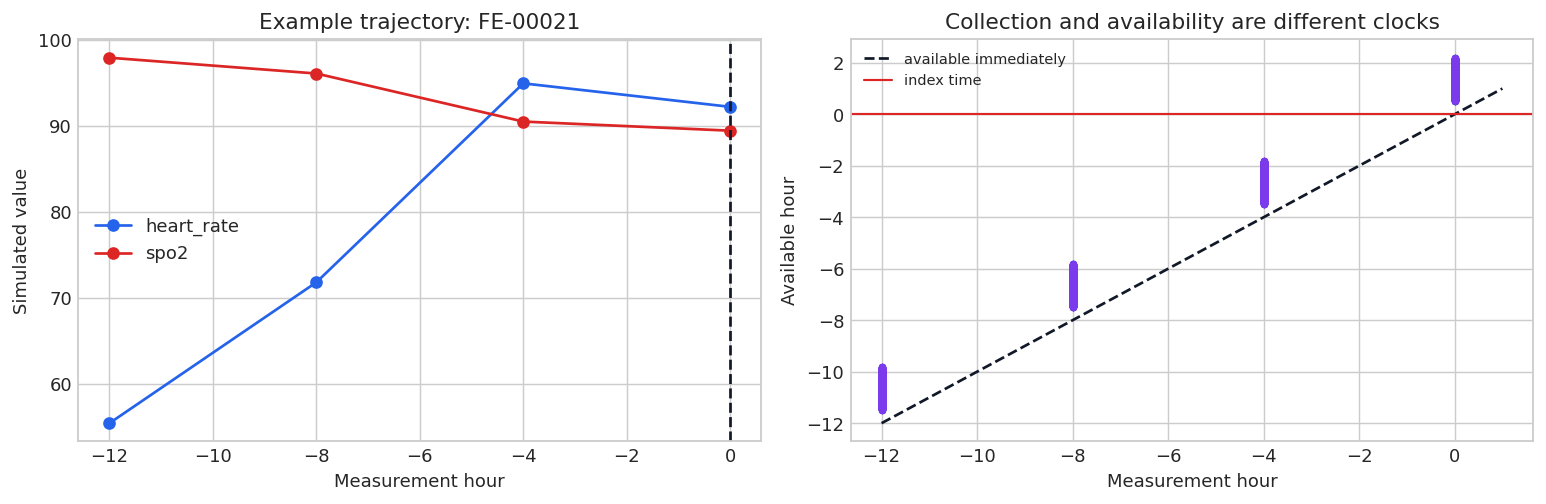

In [5]:
# Choose a patient with several observations so the teaching plot is informative.
heart_rate_counts = (
    observations.loc[observations.variable == "heart_rate"]
    .groupby("patient_id").size().sort_values(ascending=False)
)
example_patient = heart_rate_counts.index[0]
example_events = observations.loc[observations.patient_id == example_patient].copy()

# Phase 1: show values on their clinical measurement clock.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for variable, colour in [("heart_rate", "#2563eb"), ("spo2", "#dc2626")]:
    subset = example_events.loc[example_events.variable == variable]
    axes[0].plot(subset.measurement_hour, subset.value, marker="o",
                 label=variable, color=colour)
axes[0].axvline(0, color="#111827", linestyle="--")
axes[0].set(title=f"Example trajectory: {example_patient}",
            xlabel="Measurement hour", ylabel="Simulated value")
axes[0].legend()

# The second panel makes delayed result availability visible.
lab_events = observations.loc[observations.variable == "creatinine"]
axes[1].scatter(lab_events.measurement_hour, lab_events.available_hour,
                s=9, alpha=0.25, color="#7c3aed")
axes[1].plot([-12, 1], [-12, 1], color="#111827", linestyle="--",
             label="available immediately")
axes[1].axhline(0, color="#dc2626", linewidth=1.2, label="index time")
axes[1].set(title="Collection and availability are different clocks",
            xlabel="Measurement hour", ylabel="Available hour")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


Patient-specific baselines make the absolute value noisy, while a trend across several values may reveal worsening. The laboratory scatter also shows why some time-0 specimens sit above the red availability boundary: they exist retrospectively but were not known when prediction occurred.

Before feature engineering, always inspect representative trajectories, sampling counts, units, extreme values, duplicated timestamps, and delay distributions. A perfectly functioning aggregation can still produce nonsense if upstream events are mislabelled or measured in inconsistent units.


## 4. Apply a point-in-time availability filter

The safe input table must satisfy all three conditions:

```text
measurement_hour >= -12
measurement_hour <= 0
available_hour   <= 0
```

We filter before aggregation. If filtering occurred afterward, a “last” or “maximum” operation could already have incorporated an unavailable value. We also retain exclusion counts as data-quality metrics; an unexpected increase in delayed results after deployment could indicate an interface or workflow change.


In [6]:
# Evaluate each eligibility rule separately so exclusions are auditable.
in_lookback = observations.measurement_hour.between(-12, 0, inclusive="both")
available_by_index = observations.available_hour <= 0
safe_mask = in_lookback & available_by_index

safe_observations = observations.loc[safe_mask].copy()
excluded_late_results = observations.loc[in_lookback & ~available_by_index].copy()

availability_audit = pd.DataFrame({
    "category": ["all generated observations", "eligible at index", "excluded: reported after index"],
    "rows": [len(observations), len(safe_observations), len(excluded_late_results)],
})
availability_audit["percent_of_all"] = availability_audit.rows / len(observations)
display(availability_audit.round({"percent_of_all": 3}))

# A tiny assertion makes the prediction-time contract executable.
assert safe_observations.measurement_hour.max() <= 0
assert safe_observations.available_hour.max() <= 0


,category,rows,percent_of_all
0,all generated observations,52997,1.000
1,eligible at index,39312,0.742
2,excluded: reported after index,13685,0.258


The assertion does not prove the source timestamps are semantically correct; it proves that rows labelled as future by our source do not enter the safe table. In production, teams should trace how each timestamp is generated and whether later corrections overwrite historical values. A point-in-time feature store or temporal database can help reproduce exactly what the model would have known at a past index time.


## 5. Turn irregular events into auditable encounter-level features

We will calculate the following for each patient–variable pair:

| Feature | Plain-language meaning | Important edge case |
|---|---|---|
| `last` | Most recent eligible value | Depends on correct availability filtering |
| `mean` | Average eligible value | Can hide a sharp late change |
| `min`, `max`, `range` | Observed spread and extremes | Sensitive to outliers and measurement count |
| `std` | Within-window variability | Undefined with fewer than two values |
| `delta` | Last minus first value | Confounds change with irregular spacing |
| `slope` | Linear change per hour | Requires at least two distinct times; assumes linearity |
| `count` | Number of eligible measurements | Often reflects workflow as well as physiology |
| `time_since_last` | Recency at the index | Large when observation is sparse |
| `was_measured` | Whether any eligible value exists | Explicit missingness/process signal |

These are hypotheses, not universally “good” features. The appropriate lookback and aggregation depend on the clinical question, measurement process, intervention timing, and intended use.


In [7]:
def aggregate_one_variable(group: pd.DataFrame) -> pd.Series:
    '''Summarize one patient's eligible observations for one variable.'''

    # Sorting is essential: input row order is not a reliable clinical clock.
    ordered = group.sort_values("measurement_hour")
    times = ordered.measurement_hour.to_numpy(dtype=float)
    values = ordered.value.to_numpy(dtype=float)
    count = len(values)

    # Slope needs at least two distinct times. Returning NaN lets the later
    # training-only imputer handle the undefined value without fabricating it here.
    if count >= 2 and np.unique(times).size >= 2:
        slope = np.polyfit(times, values, deg=1)[0]
        delta = values[-1] - values[0]
    else:
        slope = np.nan
        delta = np.nan

    return pd.Series({
        "last": values[-1],
        "mean": values.mean(),
        "min": values.min(),
        "max": values.max(),
        "range": values.max() - values.min(),
        "std": values.std(ddof=1) if count >= 2 else np.nan,
        "delta": delta,
        "slope": slope,
        "count": float(count),
        "time_since_last": -times[-1],  # index is hour 0
        "was_measured": 1.0,
    })


# Aggregate only after applying the availability filter.
aggregated = (
    safe_observations.groupby(["patient_id", "variable"], sort=False)
    .apply(aggregate_one_variable, include_groups=False)
    .unstack("variable")
)

# Flatten the two-level columns from (feature, variable) to variable_feature.
aggregated.columns = [f"{variable}_{feature}" for feature, variable in aggregated.columns]
aggregated = aggregated.reset_index()

# Reindex onto every patient so a completely unmeasured variable remains visible.
features = patients.merge(aggregated, on="patient_id", how="left", validate="one_to_one")

# For missing patient-variable pairs, counts and indicators have semantic zeros.
# Value summaries remain NaN and will be imputed inside each model pipeline.
for variable in variable_specs:
    features[f"{variable}_count"] = features[f"{variable}_count"].fillna(0.0)
    features[f"{variable}_was_measured"] = features[f"{variable}_was_measured"].fillna(0.0)

# Fixed, domain-style composites combine several noisy measurements. The
# constants are reference scales declared by the generator—not statistics
# learned from the full dataset—so this step does not inspect test labels.
snapshot_components = pd.concat([
    (features["heart_rate_last"] - 78.0) / 8.0,
    (96.0 - features["spo2_last"]) / 1.4,
    (features["respiratory_rate_last"] - 17.0) / 2.8,
    (122.0 - features["systolic_bp_last"]) / 11.0,
    (features["creatinine_last"] - 0.95) / 0.22,
], axis=1)
trajectory_components = pd.concat([
    features["heart_rate_slope"] / (10.0 / 12.0),
    -features["spo2_slope"] / (3.6 / 12.0),
    features["respiratory_rate_slope"] / (5.0 / 12.0),
    -features["systolic_bp_slope"] / (8.0 / 12.0),
    features["creatinine_slope"] / (0.30 / 12.0),
], axis=1)
features["snapshot_burden_score"] = snapshot_components.mean(axis=1, skipna=True)
features["trajectory_score"] = trajectory_components.mean(axis=1, skipna=True)
features["worsening_trend_count"] = (
    trajectory_components.gt(0).sum(axis=1).astype(float)
)

print("Encounter-level feature matrix:", features.shape)
display(features.head(3))


Encounter-level feature matrix: (3600, 64)


,patient_id,age,comorbidity_count,sex_for_audit,care_site,event_12h,creatinine_last,heart_rate_last,respiratory_rate_last,spo2_last,systolic_bp_last,creatinine_mean,heart_rate_mean,respiratory_rate_mean,spo2_mean,systolic_bp_mean,creatinine_min,heart_rate_min,respiratory_rate_min,spo2_min,...,spo2_slope,systolic_bp_slope,creatinine_count,heart_rate_count,respiratory_rate_count,spo2_count,systolic_bp_count,creatinine_time_since_last,heart_rate_time_since_last,respiratory_rate_time_since_last,spo2_time_since_last,systolic_bp_time_since_last,creatinine_was_measured,heart_rate_was_measured,respiratory_rate_was_measured,spo2_was_measured,systolic_bp_was_measured,snapshot_burden_score,trajectory_score,worsening_trend_count
0,FE-00000,66.6,0,F,A,0,0.501534,85.642417,16.860018,93.661271,121.637502,0.501534,84.819830,16.444763,95.644259,130.015178,0.501534,83.997244,16.029507,93.661271,...,-0.506920,-1.402489,1.0,2.0,2.0,3.0,3.0,12.0,4.0,8.0,4.0,4.0,1.0,1.0,1.0,1.0,1.0,0.114060,1.134637,4.0
1,FE-00001,46.4,3,F,A,0,1.276009,90.596423,15.879627,96.467766,137.740539,1.249323,85.633887,14.664333,98.221191,137.740539,1.222637,80.671351,13.449039,96.467766,...,-0.477827,NaN,2.0,2.0,2.0,3.0,1.0,4.0,8.0,4.0,4.0,8.0,1.0,1.0,1.0,1.0,1.0,0.178241,1.391579,4.0
2,FE-00002,73.3,0,F,C,0,0.574019,NaN,20.240223,93.765200,121.422025,0.669090,NaN,19.375323,94.245606,123.982290,0.574019,NaN,18.510422,93.765200,...,-0.068321,0.735203,2.0,0.0,2.0,3.0,3.0,4.0,NaN,4.0,4.0,4.0,1.0,0.0,1.0,1.0,1.0,0.274262,-0.326709,2.0


The result has one row per prediction. Some slopes, deltas, and standard deviations remain missing because they are mathematically undefined with fewer than two observations. We do not fill them with a global median yet. Imputation is a learned transformation and therefore belongs inside a pipeline fitted on training data only.

We also distinguish “not measured” from “measured but value summary missing.” A semantic zero is appropriate for `count` and `was_measured`; it would be inappropriate for creatinine or oxygen saturation.


## 6. Split patients before fitting any learned transform

The unit is one encounter per fictional patient, so a row-wise split is also a patient-level split here. Longitudinal projects with multiple encounters per patient must group all of a patient's rows together—or use a time-based split aligned to intended deployment.

We reserve four partitions:

- **training (55%)** fits candidate pipelines;
- **validation (15%)** selects the feature set and model family;
- **calibration (15%)** selects one operating threshold after the family is frozen;
- **test (15%)** is opened once for final reporting.

This extra calibration partition solves a subtle problem. A threshold chosen from probabilities produced by one fitted model should not be applied to probabilities from a differently refitted model without checking scale. Here, the selected family is refitted on training + validation, and that same fitted model produces both calibration and test probabilities.


In [8]:
all_indices = np.arange(len(features))

# First isolate the untouched 15% test partition.
development_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.15,
    stratify=features.event_12h,
    random_state=RANDOM_SEED,
)

# From the remaining 85%, allocate 15% of the full sample to calibration.
train_validation_indices, calibration_indices = train_test_split(
    development_indices,
    test_size=0.15 / 0.85,
    stratify=features.event_12h.iloc[development_indices],
    random_state=RANDOM_SEED + 1,
)

# Finally, split 55% training and 15% validation from 70% of the full sample.
train_indices, validation_indices = train_test_split(
    train_validation_indices,
    test_size=0.15 / 0.70,
    stratify=features.event_12h.iloc[train_validation_indices],
    random_state=RANDOM_SEED + 2,
)

split_summary = pd.DataFrame([
    {"split": name, "patients": len(indices),
     "events": int(features.event_12h.iloc[indices].sum()),
     "prevalence": features.event_12h.iloc[indices].mean()}
    for name, indices in [
        ("train", train_indices), ("validation", validation_indices),
        ("calibration", calibration_indices), ("test", test_indices),
    ]
])
display(split_summary.round({"prevalence": 3}))

# Disjointness is an executable guard against accidental patient reuse.
split_sets = [set(x) for x in [train_indices, validation_indices,
                                calibration_indices, test_indices]]
assert sum(len(x) for x in split_sets) == len(set.union(*split_sets))


,split,patients,events,prevalence
0,train,1980,569,0.287
1,validation,540,155,0.287
2,calibration,540,155,0.287
3,test,540,155,0.287


## 7. Define a weaker-to-stronger model ladder

We compare five candidates. The first isolates the information in prevalence alone. The next two isolate the value of feature engineering while keeping the model family fixed. The final two ask whether nonlinear models can recover interactions that logistic regression cannot represent without manually adding interaction terms.

| Candidate | Inputs | Model | Learning question |
|---|---|---|---|
| Prevalence baseline | No patient-specific signal | Dummy classifier | How much do we gain beyond class frequency? |
| Last-value logistic | Demographics + last values + measurement indicators | Logistic regression | What can a simple snapshot learn? |
| Engineered logistic | Snapshot + trend, variability, range, recency, count | Logistic regression | Do temporal summaries help without changing model family? |
| Engineered random forest | Full engineered set | Bagged decision trees | Do nonlinear splits and interactions add value? |
| Engineered gradient boosting | Full engineered set | Sequentially boosted shallow trees | Can error-correcting tree stages provide a further modest gain? |

Complexity does not guarantee improvement on real data. This generator contains some nonlinear and trajectory signal so a modest ladder is possible, but stochastic outcomes and unmeasured context limit every valid model.


In [9]:
# Identify feature groups by suffix so the specification remains auditable.
identifier_columns = {"patient_id", "event_12h", "sex_for_audit"}
context_numeric = ["age", "comorbidity_count"]
categorical = ["care_site"]

# Construct exact names: `endswith("_last")` would also (incorrectly)
# capture every `*_time_since_last` recency feature in the weak snapshot.
last_value_numeric = (
    context_numeric
    + [f"{variable}_last" for variable in variable_specs]
    + [f"{variable}_was_measured" for variable in variable_specs]
)

# Use a purposeful rather than exhaustive engineered set. Mean/min/max are
# omitted because they duplicate much of last/range information in this
# short window and can add variance without answering a new question.
engineered_suffixes = (
    "_last", "_delta", "_slope", "_std", "_range",
    "_time_since_last", "_count", "_was_measured",
)
derived_composites = [
    "snapshot_burden_score", "trajectory_score", "worsening_trend_count",
]
engineered_numeric = context_numeric + sorted([
    column for column in features.columns
    if column not in context_numeric + derived_composites
    and column.endswith(engineered_suffixes)
]) + derived_composites


def make_preprocessor(numeric_columns: list[str], scale: bool) -> ColumnTransformer:
    '''Create train-fitted numeric and categorical preprocessing.'''
    numeric_steps: list[tuple[str, Any]] = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ]
    if scale:
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numeric_columns),
        ("site", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
    ], remainder="drop")


def make_pipeline(family: str, numeric_columns: list[str]) -> Pipeline:
    '''Construct one candidate with all learned preprocessing inside it.'''
    if family == "dummy":
        # The preprocessor keeps the interface consistent; Dummy ignores X.
        model = DummyClassifier(strategy="prior")
        return Pipeline([("preprocess", make_preprocessor(context_numeric, False)),
                         ("model", model)])
    if family == "logistic":
        # Moderate regularization is important because trend summaries are
        # correlated. The value is fixed before validation comparison.
        model = LogisticRegression(max_iter=2_000, C=0.15)
        return Pipeline([("preprocess", make_preprocessor(numeric_columns, True)),
                         ("model", model)])
    if family == "forest":
        model = RandomForestClassifier(
            n_estimators=400, max_depth=8, min_samples_leaf=16, max_features=0.75,
            # One worker is slower than unrestricted multiprocessing but is
            # reliable in Colab and other memory-constrained teaching runtimes.
            class_weight="balanced_subsample", n_jobs=1,
            random_state=RANDOM_SEED,
        )
        return Pipeline([("preprocess", make_preprocessor(numeric_columns, False)),
                         ("model", model)])
    if family == "boosting":
        # Shallow sequential trees can recover threshold interactions while
        # leaf-size and learning-rate constraints limit overfitting.
        model = GradientBoostingClassifier(
            n_estimators=180, learning_rate=0.02, max_depth=3,
            min_samples_leaf=10, random_state=RANDOM_SEED,
        )
        return Pipeline([("preprocess", make_preprocessor(numeric_columns, False)),
                         ("model", model)])
    raise ValueError(f"Unknown model family: {family}")


candidate_specs = {
    "Prevalence baseline": ("dummy", context_numeric),
    "Last-value logistic": ("logistic", last_value_numeric),
    "Engineered logistic": ("logistic", engineered_numeric),
    "Engineered random forest": ("forest", engineered_numeric),
    "Engineered gradient boosting": ("boosting", engineered_numeric),
}

print(f"Last-value numeric features: {len(last_value_numeric)}")
print(f"Engineered numeric features: {len(engineered_numeric)}")


Last-value numeric features: 12
Engineered numeric features: 45


Two details prevent subtle leakage. First, median imputation, missingness-indicator creation, scaling, and one-hot encoding are fitted inside each training pipeline. Second, the validation and test labels never influence those transformations.

We will compare three probability metrics. AUROC measures ranking across all thresholds. AUPRC focuses more strongly on the positive class and should always be interpreted relative to event prevalence. Brier score measures squared probability error, so lower is better and calibration matters.


In [10]:
def probability_metrics(labels: np.ndarray, probabilities: np.ndarray) -> dict[str, float]:
    '''Return complementary discrimination and probability-error metrics.'''
    return {
        "AUROC": roc_auc_score(labels, probabilities),
        "AUPRC": average_precision_score(labels, probabilities),
        "Brier": brier_score_loss(labels, probabilities),
    }


# Phase 1: expose only train and validation partitions during model selection.
X_train = features.iloc[train_indices]
y_train = features.event_12h.iloc[train_indices].to_numpy()
X_validation = features.iloc[validation_indices]
y_validation = features.event_12h.iloc[validation_indices].to_numpy()

# Phase 2: retain fitted pipelines and probabilities for transparent comparison.
fitted_candidates: dict[str, Pipeline] = {}
validation_probabilities: dict[str, np.ndarray] = {}
validation_rows: list[dict] = []

# Phase 3: fit every learned transform on training data only.
for candidate_name, (family, numeric_columns) in candidate_specs.items():
    started = time.perf_counter()
    pipeline = make_pipeline(family, numeric_columns)

    # Only the training partition fits preprocessing and model parameters.
    pipeline.fit(X_train[numeric_columns + categorical], y_train)
    probabilities = pipeline.predict_proba(
        X_validation[numeric_columns + categorical]
    )[:, 1]

    validation_rows.append({
        "candidate": candidate_name,
        **probability_metrics(y_validation, probabilities),
        "fit_seconds": time.perf_counter() - started,
    })
    fitted_candidates[candidate_name] = pipeline
    validation_probabilities[candidate_name] = probabilities

validation_results = pd.DataFrame(validation_rows).sort_values(
    "AUPRC", ascending=False
).reset_index(drop=True)
display(validation_results.round({
    "AUROC": 3, "AUPRC": 3, "Brier": 3, "fit_seconds": 2,
}))


,candidate,AUROC,AUPRC,Brier,fit_seconds
0,Engineered gradient boosting,0.717,0.543,0.178,3.26
1,Engineered logistic,0.715,0.528,0.180,0.27
2,Engineered random forest,0.707,0.520,0.204,9.66
3,Last-value logistic,0.648,0.409,0.194,0.06
4,Prevalence baseline,0.500,0.287,0.205,0.02


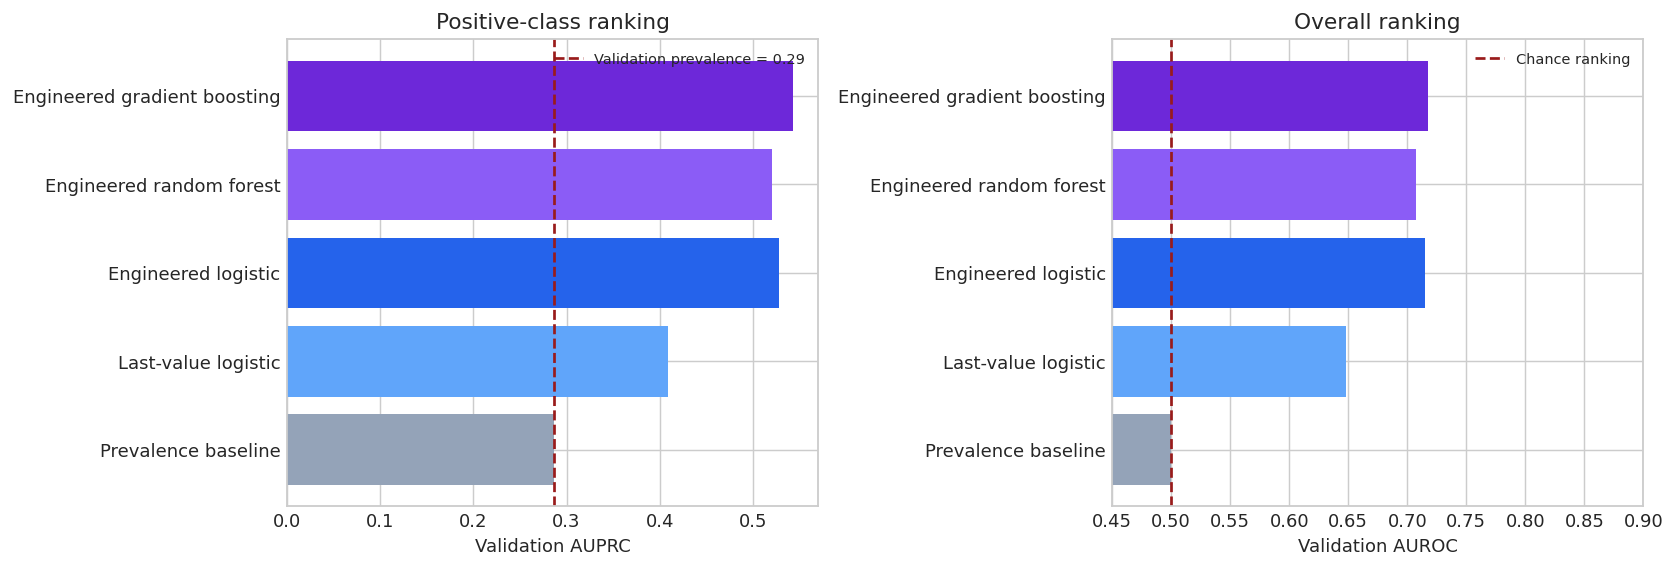

In [11]:
# Plot the validation ladder in the intended conceptual order rather than
# sorting bars by performance after seeing the results.
ladder_order = list(candidate_specs)
ladder = validation_results.set_index("candidate").loc[ladder_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colours = ["#94a3b8", "#60a5fa", "#2563eb", "#8b5cf6", "#6d28d9"]
axes[0].barh(ladder_order, ladder.AUPRC, color=colours)
axes[0].axvline(y_validation.mean(), color="#991b1b", linestyle="--",
                label=f"Validation prevalence = {y_validation.mean():.2f}")
axes[0].set(xlabel="Validation AUPRC", title="Positive-class ranking")
axes[0].legend(fontsize=8)

axes[1].barh(ladder_order, ladder.AUROC, color=colours)
axes[1].axvline(0.5, color="#991b1b", linestyle="--", label="Chance ranking")
axes[1].set(xlabel="Validation AUROC", xlim=(0.45, 0.9), title="Overall ranking")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


### How to interpret these results

Read the table across metrics rather than treating it as a beauty contest. In the stored validation run, the prevalence baseline anchors AUROC at **0.500** and AUPRC at the **0.287** event prevalence. Last-value logistic regression reaches **0.648 AUROC / 0.409 AUPRC**. Keeping logistic regression fixed while adding changes, slopes, variability, ranges, recency, and counts raises performance to **0.715 / 0.528**. Gradient boosting is selected with **0.717 / 0.543**—a modest AUPRC gain of 0.015 over engineered logistic, not a dramatic leap. The random forest reaches 0.707 / 0.520 and therefore illustrates that a nominally more flexible family need not win.

The prevalence baseline has no ranking ability. Last-value logistic regression learns a modest snapshot signal. The engineered logistic model isolates the value of temporal summaries without changing the classifier. The tree ensembles can exploit nonlinearities and interactions, but their improvement is incremental rather than magical.

Because validation contains only a few hundred encounters, small differences may be sampling noise. We choose the candidate with the highest validation AUPRC for this tutorial, but a real protocol should specify the primary metric, minimum clinically relevant improvement, calibration requirements, subgroup checks, resource constraints, and tie-breaking rule in advance.


## 8. Freeze the family, refit on development data, and choose a threshold

We now make the only model-selection decision: choose the highest validation AUPRC. We then reconstruct that pipeline from scratch and fit it on training + validation. The calibration split is used only to select an operating threshold; it does not update model parameters.

The threshold will maximize F1 on calibration data for demonstration. F1 balances precision and recall mathematically, but it does not encode clinical harm, resource limits, or alert fatigue. A real threshold should be tied to intended action, capacity, and the relative consequences of missed and false alerts.


In [12]:
selected_name = validation_results.iloc[0].candidate
selected_family, selected_numeric = candidate_specs[selected_name]

# Recreate the selected pipeline so no fitted candidate state is reused accidentally.
final_model = make_pipeline(selected_family, selected_numeric)
development_fit_indices = np.concatenate([train_indices, validation_indices])
final_model.fit(
    features.iloc[development_fit_indices][selected_numeric + categorical],
    features.event_12h.iloc[development_fit_indices],
)

# The same fitted model generates calibration and later test probabilities,
# keeping the operating threshold on a consistent probability scale.
calibration_probabilities = final_model.predict_proba(
    features.iloc[calibration_indices][selected_numeric + categorical]
)[:, 1]
calibration_labels = features.event_12h.iloc[calibration_indices].to_numpy()

candidate_thresholds = np.linspace(0.05, 0.80, 151)
threshold_scores = np.array([
    f1_score(calibration_labels, calibration_probabilities >= threshold)
    for threshold in candidate_thresholds
])
selected_threshold = float(candidate_thresholds[np.argmax(threshold_scores)])

print("Selected on validation:", selected_name)
print(f"Calibration-selected threshold: {selected_threshold:.3f}")
print(f"Calibration F1 at threshold: {threshold_scores.max():.3f}")


Selected on validation: Engineered gradient boosting
Calibration-selected threshold: 0.235
Calibration F1 at threshold: 0.500


The selected threshold is not 0.5 by default because class prevalence, calibration, and the chosen objective all affect the useful operating point. Crucially, it was selected without looking at the test labels. We now open the test partition once and report both probability metrics and threshold-dependent operating metrics.


In [13]:
# Phase 1: open the locked test partition only after family and threshold freeze.
X_test = features.iloc[test_indices][selected_numeric + categorical]
y_test = features.event_12h.iloc[test_indices].to_numpy()
test_probabilities = final_model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= selected_threshold).astype(int)

# Derive the full confusion matrix explicitly so workload metrics are transparent.
tn, fp, fn, tp = confusion_matrix(y_test, test_predictions, labels=[0, 1]).ravel()
# Phase 2: report probability quality, error rates, and alert workload together.
test_metrics = {
    **probability_metrics(y_test, test_probabilities),
    "sensitivity": recall_score(y_test, test_predictions, zero_division=0),
    "specificity": tn / (tn + fp),
    "PPV": precision_score(y_test, test_predictions, zero_division=0),
    "alerts_per_100": 100 * test_predictions.mean(),
}

# Phase 3: keep one compact record suitable for downstream reporting.
test_report = pd.DataFrame([{"model": selected_name, **test_metrics}])
display(test_report.round({
    "AUROC": 3, "AUPRC": 3, "Brier": 3,
    "sensitivity": 3, "specificity": 3, "PPV": 3,
    "alerts_per_100": 1,
}))
print(f"Test confusion counts — TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")


Test confusion counts — TP: 128, FP: 203, TN: 182, FN: 27


,model,AUROC,AUPRC,Brier,sensitivity,specificity,PPV,alerts_per_100
0,Engineered gradient boosting,0.717,0.509,0.181,0.826,0.473,0.387,61.3


**Stored test interpretation.** The locked test result is **0.717 AUROC, 0.509 AUPRC, and 0.181 Brier score**. At the calibration-selected threshold of 0.235, sensitivity is **0.826**, specificity **0.473**, and PPV **0.387**. The model would flag **61.3 of every 100** fictional encounters (128 true positives and 203 false positives), which makes the cost of maximizing F1 visible: high sensitivity comes with substantial workload and modest precision.

“Alerts per 100 encounters” makes operational burden visible. Sensitivity describes the fraction of simulated events detected, specificity the fraction of non-events not alerted, and positive predictive value the fraction of alerts that are events in this sample. All three depend on the chosen threshold; PPV and workload also depend strongly on prevalence.

The point estimates should remain moderate. That is not a defect in the notebook. The generator deliberately includes hidden context and stochastic outcomes, so even a model aligned with the generating process cannot perfectly separate cases.


### Optional: quantify sampling uncertainty

A single test score conceals uncertainty. We bootstrap patients in the locked test set and recompute AUROC and AUPRC. The interval captures sampling variability under this synthetic case distribution; it does not capture dataset shift, label error, model-selection uncertainty, or the mismatch between simulation and healthcare.


In [14]:
# Phase 1: use an independent seed so uncertainty sampling is reproducible.
bootstrap_rng = np.random.default_rng(RANDOM_SEED + 100)
bootstrap_rows = []

# Phase 2: resample whole patient rows, preserving the unit of analysis.
for _ in range(500):
    sampled = bootstrap_rng.integers(0, len(y_test), len(y_test))
    sampled_labels = y_test[sampled]
    # Some rare bootstrap samples can contain one class; skip undefined AUROC.
    if np.unique(sampled_labels).size < 2:
        continue
    sampled_probabilities = test_probabilities[sampled]
    bootstrap_rows.append({
        "AUROC": roc_auc_score(sampled_labels, sampled_probabilities),
        "AUPRC": average_precision_score(sampled_labels, sampled_probabilities),
    })

bootstrap_results = pd.DataFrame(bootstrap_rows)
# Phase 3: place point estimates beside percentile intervals for interpretation.
interval_table = pd.DataFrame([
    {"metric": metric,
     "estimate": test_metrics[metric],
     "2.5%": bootstrap_results[metric].quantile(0.025),
     "97.5%": bootstrap_results[metric].quantile(0.975)}
    for metric in ["AUROC", "AUPRC"]
])
display(interval_table.round({"estimate": 3, "2.5%": 3, "97.5%": 3}))


,metric,estimate,2.5%,97.5%
0,AUROC,0.717,0.668,0.764
1,AUPRC,0.509,0.436,0.596


In this run, the patient bootstrap gives a **95% percentile interval of 0.668–0.764 for AUROC** and **0.436–0.596 for AUPRC**. These intervals are wide enough to cover performance differences much larger than the 0.015 validation-AUPRC gap between engineered logistic regression and boosting. This is why a small numeric improvement should not automatically be called meaningful. Prospective impact depends on who receives the prediction, what action follows, how often the system abstains, and whether errors concentrate in particular settings or groups.


## 9. Deliberately add a future feature

We now break the prediction contract on purpose. `future_spo2` is measured six hours after the hour-0 index, inside the outcome window. It is moderately associated with the outcome but contains substantial noise, so the leaked score should improve without becoming absurdly close to 1.0.

This model is **not a candidate**. It is trained only after the valid family has been selected and the valid test result reported. Its sole purpose is to show that an apparently better metric can reveal an operationally impossible pipeline.


In [15]:
# Merge the prohibited +6-hour value only for this red-flag demonstration.
leaked_features = features.merge(
    future_spo2[["patient_id", "future_spo2"]],
    on="patient_id", how="left", validate="one_to_one",
)
leaked_numeric = selected_numeric + ["future_spo2"]

# Phase 1: keep the same selected family so the only conceptual change is timing.
leaked_model = make_pipeline(selected_family, leaked_numeric)
leaked_model.fit(
    leaked_features.iloc[development_fit_indices][leaked_numeric + categorical],
    leaked_features.event_12h.iloc[development_fit_indices],
)
leaked_test_probabilities = leaked_model.predict_proba(
    leaked_features.iloc[test_indices][leaked_numeric + categorical]
)[:, 1]
leaked_metrics = probability_metrics(y_test, leaked_test_probabilities)

# Phase 2: compare probability metrics, never promote the invalid model.
leakage_comparison = pd.DataFrame([
    {"pipeline": "Valid point-in-time pipeline", **probability_metrics(y_test, test_probabilities)},
    {"pipeline": "INVALID: includes +6 h SpO2", **leaked_metrics},
])
display(leakage_comparison.round({"AUROC": 3, "AUPRC": 3, "Brier": 3}))


,pipeline,AUROC,AUPRC,Brier
0,Valid point-in-time pipeline,0.717,0.509,0.181
1,INVALID: includes +6 h SpO2,0.772,0.574,0.167


:::{admonition} A better score can identify a broken pipeline
:class: warning
In the stored run, adding the prohibited +6-hour measurement raises test AUROC from **0.717 to 0.772** and AUPRC from **0.509 to 0.574**. The leaked model ranks outcomes better because it sees a measurement taken after prediction, when deterioration may already be unfolding. It answers “Who looks worse six hours later?” rather than “What could we know at hour 0?” The improvement is invalid, even though the code runs and the metric is mathematically correct.
:::

Leakage is often less obvious than a column named `future_spo2`. Examples include discharge disposition, treatment initiated after deterioration, a diagnosis code assigned at the end of an encounter, a report finalized after prediction, or imputation fitted on the entire dataset. The defense is a precise prediction contract plus point-in-time data reconstruction—not merely deleting suspicious column names.


## 10. Optional diagnostics: calibration and permutation importance

Calibration asks whether predictions near 0.30 correspond to events roughly 30% of the time. Discrimination and calibration are different properties: a model may rank patients well while producing probabilities that are systematically too high or low.

Permutation importance asks how much test AUPRC decreases when one input column is shuffled. It measures dependence of this fitted pipeline on a feature under this dataset—not causality or clinical importance. Correlated summaries can divide or mask importance because shuffling one leaves related information intact.


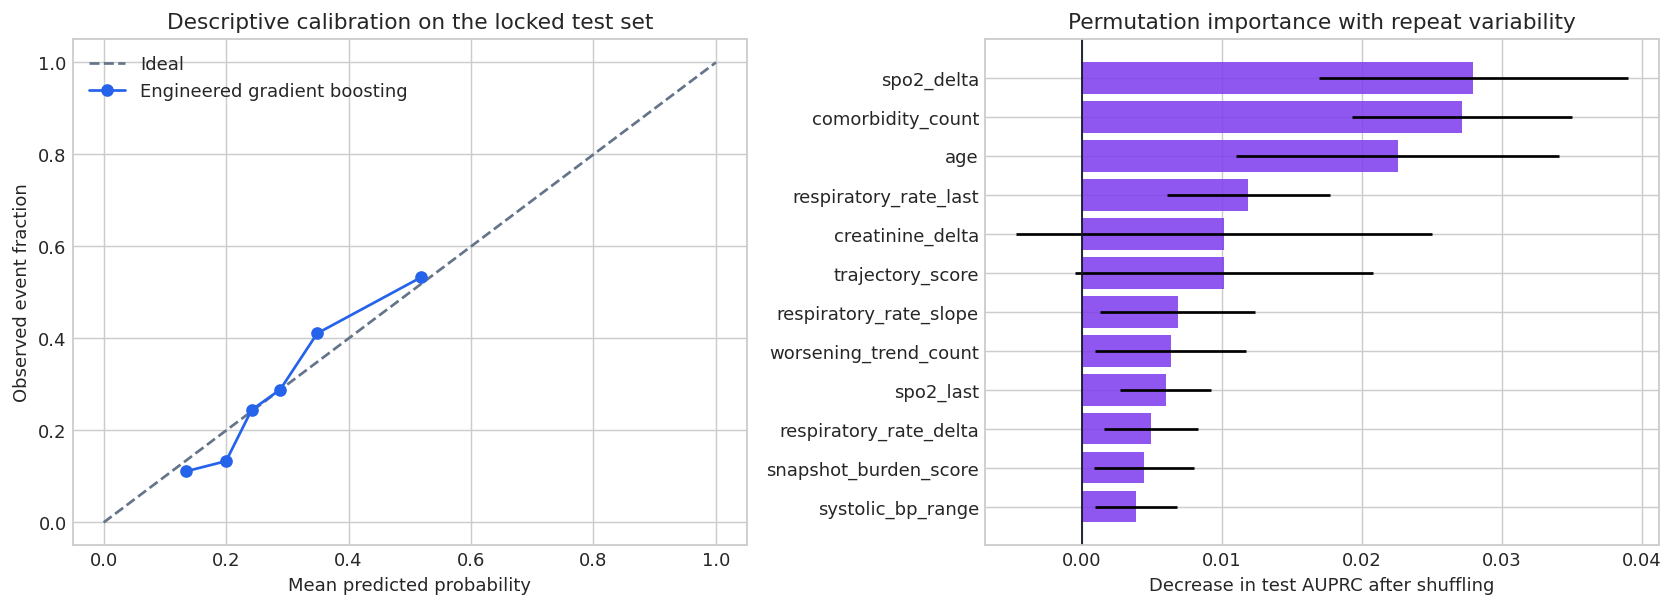

In [16]:
# Phase 1: summarize reliability in quantile bins on the locked test set.
observed_fraction, predicted_mean = calibration_curve(
    y_test, test_probabilities, n_bins=6, strategy="quantile"
)

# Score importance on a fixed subset of the locked test set for speed.
# Phase 2: perturb original input columns after the complete pipeline is fitted.
importance_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=12,
    random_state=RANDOM_SEED,
    # Avoid spawning many worker processes in small hosted runtimes.
    n_jobs=1,
)
importance = pd.DataFrame({
    "feature": selected_numeric + categorical,
    "mean": importance_result.importances_mean,
    "std": importance_result.importances_std,
}).sort_values("mean", ascending=False).head(12)

# Phase 3: present calibration and model reliance side by side.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#64748b", label="Ideal")
axes[0].plot(predicted_mean, observed_fraction, marker="o", color="#2563eb",
             label=selected_name)
axes[0].set(xlabel="Mean predicted probability", ylabel="Observed event fraction",
            title="Descriptive calibration on the locked test set")
axes[0].legend()

ordered = importance.sort_values("mean")
axes[1].barh(ordered.feature, ordered["mean"], xerr=ordered["std"],
             color="#7c3aed", alpha=0.85)
axes[1].axvline(0, color="#111827", linewidth=1)
axes[1].set(xlabel="Decrease in test AUPRC after shuffling",
            title="Permutation importance with repeat variability")
plt.tight_layout()
plt.show()


With only six calibration bins and a few hundred test patients, deviations from the diagonal are descriptive rather than definitive. Negative permutation values can occur when shuffling a noisy feature improves performance by chance. Neither plot repairs a poorly specified prediction task.

If the model were intended to output actionable probabilities, calibration should be assessed across sites, time periods, relevant groups, and prevalence shifts. Recalibration also changes the probability scale, so any operating threshold must be revalidated afterward.


## 11. Optional subgroup description and executable data-contract checks

We retained a fictional sex field for a small descriptive audit. A two-row table cannot establish fairness. Group performance estimates require sufficient sample sizes, justified group definitions, intersectional analysis, uncertainty, and examination of downstream benefit and harm—not just equal AUROC.

The final assertions encode a few non-negotiable mechanics. They are regression tests for the tutorial pipeline, not a comprehensive data validation suite.


In [17]:
audit_frame = features.iloc[test_indices][["sex_for_audit", "event_12h"]].copy()
audit_frame["probability"] = test_probabilities

subgroup_rows = []
for group_name, group in audit_frame.groupby("sex_for_audit"):
    subgroup_rows.append({
        "group": group_name,
        "n": len(group),
        "events": int(group.event_12h.sum()),
        "prevalence": group.event_12h.mean(),
        "AUROC": roc_auc_score(group.event_12h, group.probability),
        "AUPRC": average_precision_score(group.event_12h, group.probability),
    })
subgroup_table = pd.DataFrame(subgroup_rows)
display(subgroup_table.round({"prevalence": 3, "AUROC": 3, "AUPRC": 3}))

# Point-in-time invariants: no valid observation is measured or available later than index.
assert safe_observations.measurement_hour.le(0).all()
assert safe_observations.available_hour.le(0).all()

# Entity invariants: exactly one feature row and one outcome per patient.
assert features.patient_id.is_unique
assert features.event_12h.isin([0, 1]).all()

# Split invariants: no patient index appears in more than one partition.
assert len(set(train_indices) & set(test_indices)) == 0
assert len(set(validation_indices) & set(test_indices)) == 0
assert len(set(calibration_indices) & set(test_indices)) == 0

# The prohibited demonstration feature must never enter the valid specification.
assert "future_spo2" not in selected_numeric
print("All point-in-time, entity, split, and feature-contract checks passed.")


All point-in-time, entity, split, and feature-contract checks passed.


,group,n,events,prevalence,AUROC,AUPRC
0,F,269,82,0.305,0.682,0.516
1,M,271,73,0.269,0.750,0.508


Apparent subgroup differences here arise from finite synthetic samples and the generator; they do not describe sex-related performance in any population. A real audit would also examine missingness, calibration, threshold-dependent errors, alert burden, clinical follow-up, and outcomes, with affected communities involved in defining what equitable performance means.


## 12. Extending the same reasoning across modalities

The feature contract generalizes beyond vital signs:

| Modality | Candidate feature | Availability question | Common leakage path |
|---|---|---|---|
| Laboratory data | Latest, change, slope, abnormal count | Was the result finalized before index? | Using a specimen collected before but reported after index |
| Medications | Active order, administration count, dose change | Was it ordered, verified, dispensed, or administered? | Treating a later administration as a prior plan |
| Diagnoses/procedures | Prior count or recency | When was the code assigned and visible? | Using end-of-encounter coding |
| Clinical notes | Concept or embedding from signed text | Was the note signed or merely authored later? | Using a retrospective summary |
| Images | Prior model score or acquisition metadata | Was acquisition and interpretation complete? | Including a later scan or final report |
| Waveforms | Window statistics or learned representation | Did the entire signal window end before index? | A window that overlaps the outcome period |

Learned representations are still features. Text embeddings, image encoders, and sequence encoders must be fitted or selected without test leakage, versioned, monitored, and tied to the same point-in-time contract.


## 13. Practical feature-review template

For every production candidate, document:

1. **Definition:** source system, code set, units, inclusion rules, and aggregation.
2. **Time:** collection, availability, lookback, update frequency, and late corrections.
3. **Missingness:** why the value may be absent and whether that process could change.
4. **Transformation:** imputation, scaling, clipping, encoding, and fitted population.
5. **Clinical meaning:** why the feature could help at the decision point—not after it.
6. **Fragility:** workflow, site, device, documentation, or policy changes that could alter it.
7. **Governance:** owner, version, validation tests, monitoring threshold, and retirement rule.

Keep this specification beside the code. A descriptive name like `creatinine_slope` is not enough to reconstruct how the value was built.

## 14. Summary

Feature engineering begins with a prediction contract, not with a list of columns. In this tutorial, both collection and availability times had to precede the index. We then summarized an irregular history with values, changes, slopes, variability, range, recency, and missingness signals.

The controlled model ladder showed the intended pattern: prevalence was weakest; last-value logistic regression captured some signal; temporal engineering improved a simple model; and nonlinear ensembles could add a modest further gain. None of the valid results approached perfection because the outcome intentionally contained unmeasured context and random variation.

Finally, a future measurement improved the metric while invalidating the task. This is the central warning: **a model can be statistically stronger and operationally wrong**. Reproducible point-in-time data, split-safe pipelines, locked evaluation, and executable contracts are what make a feature defensible.


## References and further reading

1. Steyerberg, E. W. *Clinical Prediction Models*, 2nd ed. Springer (2019). <https://doi.org/10.1007/978-3-030-16399-0>
2. Collins, G. S. et al. “TRIPOD+AI Statement: Updated Guidance for Reporting Clinical Prediction Models That Use Regression or Machine Learning Methods.” *BMJ* 385 (2024). <https://doi.org/10.1136/bmj-2023-078378>
3. Moons, K. G. M. et al. “PROBAST+AI: An Updated Quality, Risk of Bias, and Applicability Assessment Tool for Prediction Models Using Regression or Artificial Intelligence Methods.” *BMJ* 388 (2025). <https://doi.org/10.1136/bmj-2024-082505>
4. Van Calster, B. et al. “Calibration: The Achilles Heel of Predictive Analytics.” *BMC Medicine* 17, 230 (2019). <https://doi.org/10.1186/s12916-019-1466-7>
5. Riley, R. D. et al. “Minimum Sample Size for Developing a Multivariable Prediction Model: Part II—Binary and Time-to-Event Outcomes.” *Statistics in Medicine* 38(7), 1276–1296 (2019). <https://doi.org/10.1002/sim.7992>
6. Futoma, J. et al. “The Myth of Generalisability in Clinical Research and Machine Learning in Health Care.” *The Lancet Digital Health* 2(9), e489–e492 (2020). <https://doi.org/10.1016/S2589-7500(20)30186-2>
7. Sculley, D. et al. “Hidden Technical Debt in Machine Learning Systems.” *NeurIPS* (2015). <https://papers.nips.cc/paper/5656-hidden-technical-debt-in-machine-learning-systems>

:::{admonition} Final interpretation
:class: warning
Every stored result in this notebook comes from a simulated event stream designed to teach timing, leakage, and model-development mechanics. It provides no estimate of performance, prevalence, fairness, or clinical value in any real setting.
:::
